Before we can do any machine learning, the first thing we need to deal with is the class imbalance. As can be seen in the data visualisation datasets, the regular datasets (f1_f, and f1_nt) have a rather large class imbalance. Below, we have a varity of methods to deal with it. 

threshold t: 0.2866666666666667
              precision    recall  f1-score   support

           0      0.991     0.991     0.991      1462
           1      0.831     0.831     0.831        77

    accuracy                          0.983      1539
   macro avg      0.911     0.911     0.911      1539
weighted avg      0.983     0.983     0.983      1539



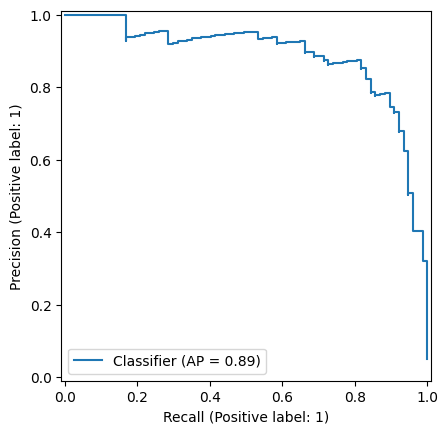

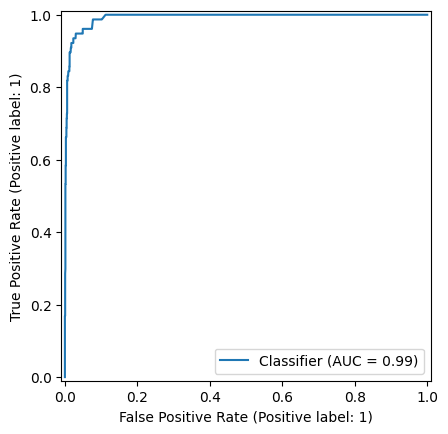

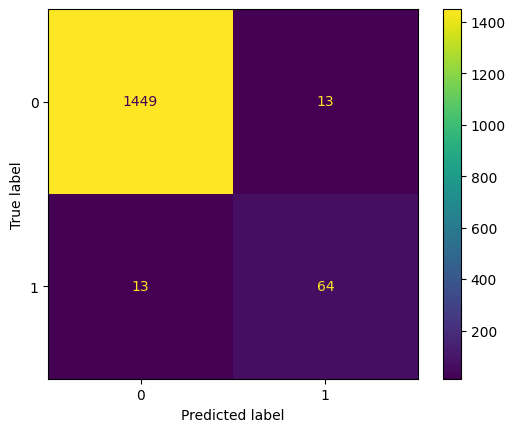

In [34]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report
import numpy as np

df = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1_nt.csv")

drop_cols = ['worldChamp','driverId','raceId','constructorId']  # remove IDs
feature_cols = [c for c in df.columns if c not in drop_cols + ['year','round']]

# time split maybe dont do this after feedback from agi --> performance is negligible so might as well keep it
train = df[df['year'] <= 2016].copy()
val   = df[(df['year'] >= 2017) & (df['year'] <= 2020)].copy()
test  = df[(df['year'] >= 2021) & (df['year'] <= 2024)].copy()

X_tr, y_tr = train[feature_cols], train['worldChamp'].astype(int)
X_va, y_va = val[feature_cols],   val['worldChamp'].astype(int)
X_te, y_te = test[feature_cols],  test['worldChamp'].astype(int)

# model with cost sensitivity
rf = RandomForestClassifier(
    n_estimators=600, max_depth=None, n_jobs=-1, random_state=42,
    class_weight='balanced'   # <-- key for imbalance
)
rf.fit(X_tr, y_tr)

# validation: probabilities + threshold tuning
p_va = rf.predict_proba(X_va)[:,1]
prec, rec, thr = precision_recall_curve(y_va, p_va)
f1 = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12)
ix = np.nanargmax(f1)
t  = float(thr[ix])
print("threshold t:", t)

# test with the SAME threshold
p_te = rf.predict_proba(X_te)[:,1]
y_hat = (p_te >= t).astype(int)
print(classification_report(y_te, y_hat, digits=3))

# plot PR and ROC curves of val and test
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
p_full = rf.predict_proba(X_te)[:,1]
PrecisionRecallDisplay.from_predictions(y_te, p_te)
RocCurveDisplay.from_predictions(y_te, p_te)
plt.show()

# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_te, y_hat)
plt.show()



In [ ]:
# retrain on full data with threshold t --> Should be same as training on whole data without a validation set anyways so its fine
X_full, y_full = df[feature_cols], df['worldChamp'].astype(int)
rf.fit(X_full, y_full)

print("FULL PR-AUC:", average_precision_score(y_full, rf.predict_proba(X_full)[:,1])) # model was trained on this data so should be very high


FULL PR-AUC: 0.995669433776899


In [17]:
# who is going to be the 2025 world champion, each round? Force it to be one champion per round each round
df_2025 = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f125_nt.csv")
X_2025 = df_2025[feature_cols]
p_2025 = rf.predict_proba(X_2025)[:,1]
df_2025['pred_worldChamp_prob'] = p_2025
df_2025['pred_worldChamp'] = (p_2025 >= t).astype(int)
df_2025 = df_2025.sort_values(['year','round','pred_worldChamp_prob'], ascending=[True,True,False])
# force one champion per round
for r in sorted(df_2025['round'].unique()):
    df_r = df_2025[df_2025['round'] == r]
    if df_r['pred_worldChamp'].sum() == 0:
        # no champion predicted, assign the highest prob one as champion
        idx_max = df_r['pred_worldChamp_prob'].idxmax()
        df_2025.loc[idx_max, 'pred_worldChamp'] = 1
    elif df_r['pred_worldChamp'].sum() > 1:
        # multiple champions predicted, keep only the highest prob one as champion
        idx_max = df_r['pred_worldChamp_prob'].idxmax()
        df_2025.loc[df_r.index, 'pred_worldChamp'] = 0
        df_2025.loc[idx_max, 'pred_worldChamp'] = 1

# driverRef is in "D:\Maastricht University\MSB1015\archive\drivers.csv", if theres no driverRef for a driverId, just mark it as unknown
drivers = pd.read_csv("d:\\Maastricht University\\MSB1015\\archive\\drivers.csv")
df_2025 = df_2025.merge(drivers[['driverId','driverRef']], on='driverId', how='left')
df_2025['driverRef'] = df_2025['driverRef'].fillna('unknown')

print(df_2025[['year','round','driverRef','pred_worldChamp_prob','pred_worldChamp']])

df_2025.to_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f125_predictions.csv", index=False)

# print after each round, who is predicted to be the world champion
for r in sorted(df_2025['round'].unique()):
    df_r = df_2025[df_2025['round'] == r]
    preds = df_r[df_r['pred_worldChamp'] == 1]
    if len(preds) == 0:
        print(f"After round {r}, no driver is predicted to be the world champion.")
    else:
        print(f"After round {r}, predicted world champion(s):")
        for _, row in preds.iterrows():
            print(f"  - {row['driverRef']} with probability {row['pred_worldChamp_prob']:.3f}")



     year  round       driverRef  pred_worldChamp_prob  pred_worldChamp
0    2025      1          norris              0.972963                1
1    2025      1         tsunoda              0.049932                0
2    2025      1  max_verstappen              0.011667                0
3    2025      1         piastri              0.011667                0
4    2025      1         russell              0.006246                0
..    ...    ...             ...                   ...              ...
315  2025     16           gasly              0.000000                0
316  2025     16         unknown              0.000000                0
317  2025     16          stroll              0.000000                0
318  2025     16          alonso              0.000000                0
319  2025     16      hulkenberg              0.000000                0

[320 rows x 5 columns]
After round 1, predicted world champion(s):
  - norris with probability 0.973
After round 2, predicted world cha

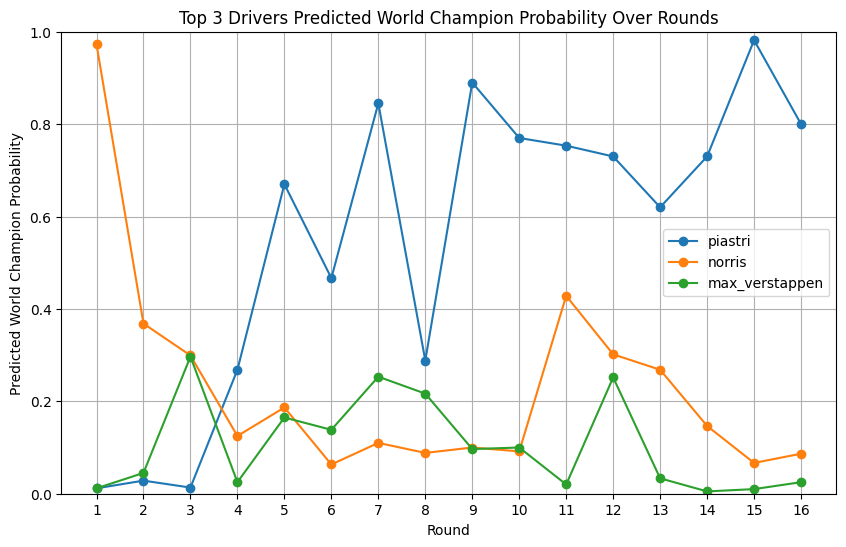

round,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
driverRef,,,,,,,,,,,,,,,,
max_verstappen,18,30,55,63,81,93,118,130,131,149,149,159,171,173,191,216
norris,25,43,61,76,88,106,124,149,167,167,192,217,235,260,260,278
piastri,2,27,42,67,92,117,132,147,172,184,202,220,245,263,288,303


In [19]:
# plot probabilities of 3 top drivers over rounds
top3_drivers = df_2025.groupby('driverRef')['pred_worldChamp_prob'].max().nlargest(3).index.tolist()
plt.figure(figsize=(10, 6))
for driver in top3_drivers:
    df_driver = df_2025[df_2025['driverRef'] == driver]
    plt.plot(df_driver['round'], df_driver['pred_worldChamp_prob'], marker='o', label=driver)
plt.xlabel('Round')
plt.ylabel('Predicted World Champion Probability')
plt.title('Top 3 Drivers Predicted World Champion Probability Over Rounds')
plt.xticks(sorted(df_2025['round'].unique()))
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

# print accumulated race points of 3 top drivers over rounds in a table
points_2025 = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f125_nt.csv")

# merge with drivers to get driverRef
points_2025 = points_2025.merge(drivers[['driverId','driverRef']], on='driverId', how='left')
points_2025['driverRef'] = points_2025['driverRef'].fillna('unknown')


points_2025 = points_2025[points_2025['driverRef'].isin(top3_drivers)]
points_2025 = points_2025.groupby(['driverRef', 'round'])['racePoints'].sum().unstack(fill_value=0)
points_2025 = points_2025.cumsum(axis=1)
display(points_2025)

# flip the table to have rounds as rows and drivers as columns
points_2025 = points_2025.T
points_2025.to_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f125_top3_driver_points.csv")

Make a similar model with f1e, in order to predict who will be future (or former) f1 champions from the current grid and their performance this year. 

VAL PR-AUC: 0.7337751936720156
Chosen threshold t=0.447 | P=0.709 R=0.629 F1=0.667
TEST PR-AUC: 0.6292730540279048
              precision    recall  f1-score   support

           0      0.776     0.807     0.792      1246
           1      0.538     0.490     0.513       569

    accuracy                          0.708      1815
   macro avg      0.657     0.649     0.652      1815
weighted avg      0.701     0.708     0.704      1815



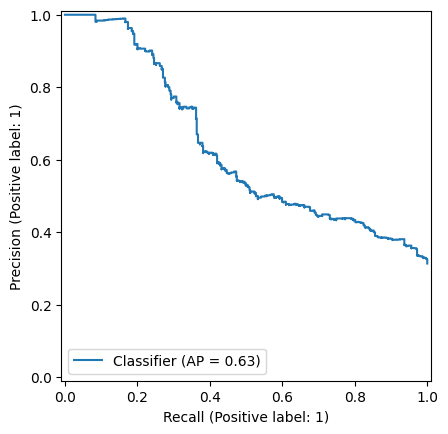

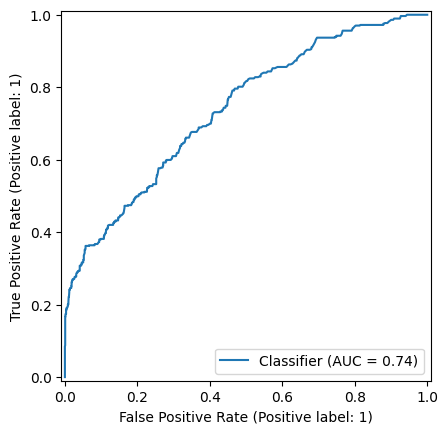

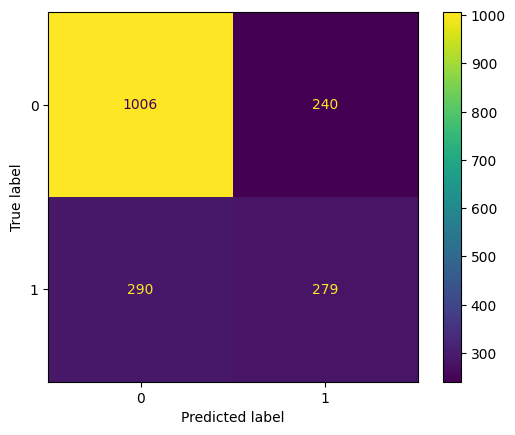

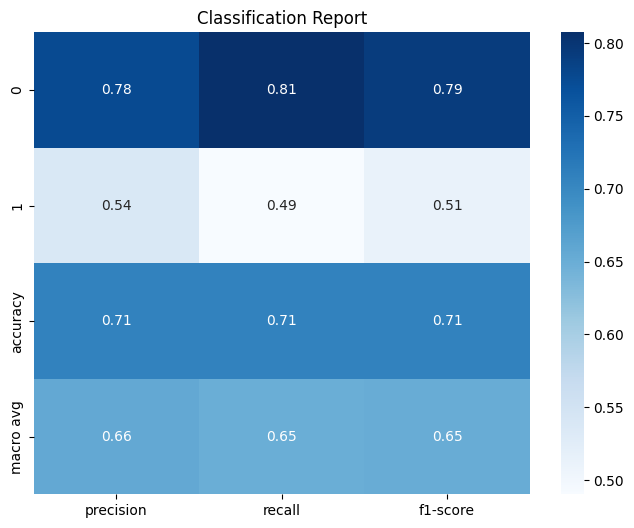

In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report
import numpy as np

# Load
df = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1e_nt.csv")

# do some class balancing by oversampling the minority class a bit less
df_minority = df[df['worldChamp'] == 1]
df_majority = df[df['worldChamp'] == 0]
df_minority_oversampled = df_minority.sample(n=len(df_majority)//2, replace=True, random_state=42)
df = pd.concat([df_majority, df_minority_oversampled])

drop_cols = ['worldChamp','driverId','raceId','constructorId']  # remove IDs
feature_cols = [c for c in df.columns if c not in drop_cols + ['year','round']]

# Time split
train = df[df['year'] <= 2016].copy()
val   = df[(df['year'] >= 2017) & (df['year'] <= 2020)].copy()
test  = df[(df['year'] >= 2021) & (df['year'] <= 2024)].copy()

X_tr, y_tr = train[feature_cols], train['worldChamp'].astype(int)
X_va, y_va = val[feature_cols],   val['worldChamp'].astype(int)
X_te, y_te = test[feature_cols],  test['worldChamp'].astype(int)

# Model with cost sensitivity
rf = RandomForestClassifier(
    n_estimators=600, max_depth=None, n_jobs=-1, random_state=42,
    class_weight='balanced'   # <-- key for imbalance
)
rf.fit(X_tr, y_tr)

# Validation: probabilities + threshold tuning (F1 or Fβ if recall matters more)
p_va = rf.predict_proba(X_va)[:,1]
prec, rec, thr = precision_recall_curve(y_va, p_va)
f1 = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12)
ix = np.nanargmax(f1)
t  = float(thr[ix])

print("VAL PR-AUC:", average_precision_score(y_va, p_va))
print(f"Chosen threshold t={t:.3f} | P={prec[ix]:.3f} R={rec[ix]:.3f} F1={f1[ix]:.3f}")

# Test with the SAME threshold
p_te = rf.predict_proba(X_te)[:,1]
y_hat = (p_te >= t).astype(int)
print("TEST PR-AUC:", average_precision_score(y_te, p_te))
print(classification_report(y_te, y_hat, digits=3))

# plot PR and ROC curves of val and test
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
p_full = rf.predict_proba(X_te)[:,1]
PrecisionRecallDisplay.from_predictions(y_te, p_te)
RocCurveDisplay.from_predictions(y_te, p_te)
plt.show()

# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_te, y_hat)
plt.show()

# plot classification report
import seaborn as sns
import matplotlib.pyplot as plt
report = classification_report(y_te, y_hat, output_dict=True)
df_report = pd.DataFrame(report).transpose()
plt.figure(figsize=(8, 6))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
plt.title('Classification Report')
plt.show()

FULL PR-AUC: 0.9985934047001126
     year  round       driverRef  pred_worldChamp_prob  pred_worldChamp
360  2025     16         piastri              0.995000                1
361  2025     16          norris              0.945000                0
362  2025     16  max_verstappen              0.736667                0
363  2025     16         leclerc              0.715000                0
364  2025     16         russell              0.598333                0
365  2025     16       antonelli              0.348333                0
367  2025     16           gasly              0.306667                0
368  2025     16       bortoleto              0.250000                0
370  2025     16           albon              0.183333                0
371  2025     16          lawson              0.163333                0
372  2025     16          alonso              0.161667                0
373  2025     16           sainz              0.125000                0
374  2025     16         bearman

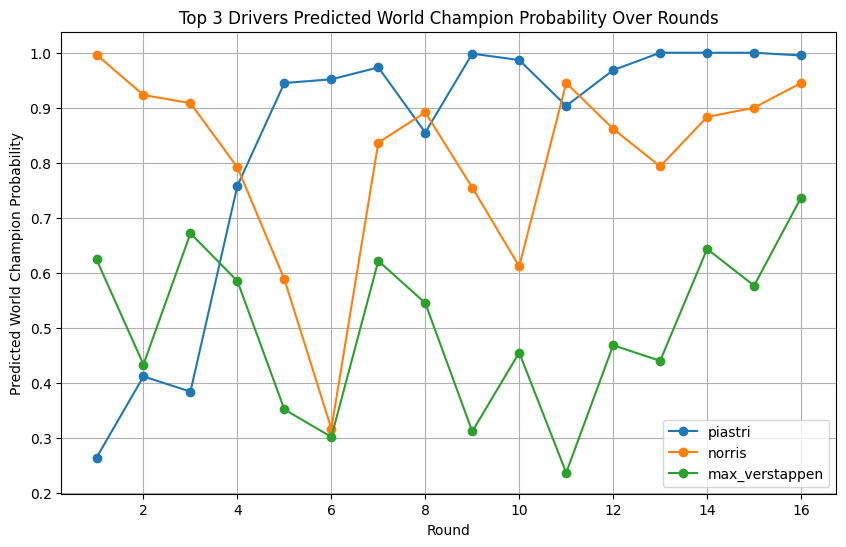

In [32]:
# give me a list of potential future champions from the current grid, retrain on full data with threshold t
df_full = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1e_nt.csv")
X_full, y_full = df_full[feature_cols], df_full['worldChamp'].astype(int)
rf.fit(X_full, y_full)
print("FULL PR-AUC:", average_precision_score(y_full, rf.predict_proba(X_full)[:,1]))

# who could potentially be a future champion from the current grid
df_2025 = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f125e_nt.csv")
X_2025 = df_2025[feature_cols]
p_2025 = rf.predict_proba(X_2025)[:,1]
df_2025['pred_worldChamp_prob'] = p_2025
df_2025['pred_worldChamp'] = (p_2025 >= t).astype(int)
df_2025 = df_2025.sort_values(['year','round','pred_worldChamp_prob'], ascending=[True,True,False])
# force one champion per round
for r in sorted(df_2025['round'].unique()):
    df_r = df_2025[df_2025['round'] == r]
    if df_r['pred_worldChamp'].sum() == 0:
        # no champion predicted, assign the highest prob one as champion
        idx_max = df_r['pred_worldChamp_prob'].idxmax()
        df_2025.loc[idx_max, 'pred_worldChamp'] = 1
    elif df_r['pred_worldChamp'].sum() > 1:
        # multiple champions predicted, keep only the highest prob one as champion
        idx_max = df_r['pred_worldChamp_prob'].idxmax()
        df_2025.loc[df_r.index, 'pred_worldChamp'] = 0
        df_2025.loc[idx_max, 'pred_worldChamp'] = 1

# driverRef is in "D:\Maastricht University\MSB1015\archive\drivers.csv", if theres no driverRef for a driverId, just mark it as unknown
drivers = pd.read_csv("d:\\Maastricht University\\MSB1015\\archive\\drivers.csv")
df_2025 = df_2025.merge(drivers[['driverId','driverRef']], on='driverId', how='left')
df_2025['driverRef'] = df_2025['driverRef'].fillna('unknown')
df_2025.to_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f125e_predictions.csv", index=False)

# give only round 16, and remove duplicates, keep the first occurrence (which is the highest prob one)
df_2025_unique = df_2025[df_2025['round'] == 16].drop_duplicates(subset=['driverRef'], keep='first')
print(df_2025_unique[['year','round','driverRef','pred_worldChamp_prob','pred_worldChamp']])

# plot probabilities of 3 top drivers, piastri, norris, and verstappen over rounds, add grid
top3_drivers = ['piastri', 'norris', 'max_verstappen']
plt.figure(figsize=(10, 6))
for driver in top3_drivers:
    df_driver = df_2025[df_2025['driverRef'] == driver]
    plt.plot(df_driver['round'], df_driver['pred_worldChamp_prob'], marker='o', label=driver)
plt.xlabel('Round')
plt.ylabel('Predicted World Champion Probability')
plt.title('Top 3 Drivers Predicted World Champion Probability Over Rounds')
plt.legend()
plt.grid()
plt.show()
